In [1]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import cohen_kappa_score, confusion_matrix

EXT_ROOT = r'E:\KNEE_fewshot\external'
EXPERTS = ['MedicalExpert-I', 'MedicalExpert-II']
IMG_EXT = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')


def list_expert(expert):
    """Return {file name: (KL grade, full path)} for one expert; grade is the leading digit of the folder."""
    items = {}
    expert_dir = os.path.join(EXT_ROOT, expert)
    for folder in sorted(os.listdir(expert_dir)):
        m = re.match(r'^(\d)', folder)
        if not m or not os.path.isdir(os.path.join(expert_dir, folder)):
            continue
        grade = int(m.group(1))
        for fname in sorted(os.listdir(os.path.join(expert_dir, folder))):
            if fname.lower().endswith(IMG_EXT):
                items[fname] = (grade, os.path.join(expert_dir, folder, fname))
    return items


labels = {e: list_expert(e) for e in EXPERTS}

for e in EXPERTS:
    grades = Counter(g for g, _ in labels[e].values())
    print(f"{e}: {len(labels[e])} images, per KL grade {[grades.get(k, 0) for k in range(5)]}")
    print(f"  sample file names: {list(labels[e])[:4]}")

    sizes, modes = Counter(), Counter()
    for fname in list(labels[e])[::50]:
        with Image.open(labels[e][fname][1]) as img:
            sizes[img.size] += 1
            modes[img.mode] += 1
    print(f"  image sizes (sampled): {dict(sizes.most_common(6))}")
    print(f"  image modes (sampled): {dict(modes)}")

common = sorted(set(labels[EXPERTS[0]]) & set(labels[EXPERTS[1]]))
only_1 = set(labels[EXPERTS[0]]) - set(labels[EXPERTS[1]])
only_2 = set(labels[EXPERTS[1]]) - set(labels[EXPERTS[0]])
print(f"\nFile names in both experts: {len(common)} | only Expert I: {len(only_1)} | only Expert II: {len(only_2)}")

if common:
    g1 = np.array([labels[EXPERTS[0]][f][0] for f in common])
    g2 = np.array([labels[EXPERTS[1]][f][0] for f in common])
    print(f"Exact agreement between experts: {(g1 == g2).mean():.3f}")
    print(f"Cohen's kappa (unweighted): {cohen_kappa_score(g1, g2):.3f}")
    print(f"Quadratic weighted kappa: {cohen_kappa_score(g1, g2, weights='quadratic'):.3f}")
    print("Expert I (rows) vs Expert II (columns), KL 0-4:")
    print(confusion_matrix(g1, g2, labels=list(range(5))))

MedicalExpert-I: 1650 images, per KL grade [514, 477, 232, 221, 206]
  sample file names: ['NormalG0 (1).png', 'NormalG0 (10).png', 'NormalG0 (100).png', 'NormalG0 (101).png']
  image sizes (sampled): {(300, 162): 29, (640, 161): 4}
  image modes (sampled): {'RGB': 31, 'I;16': 2}
MedicalExpert-II: 1650 images, per KL grade [503, 488, 232, 221, 206]
  sample file names: ['NormalG0 (1).png', 'NormalG0 (10).png', 'NormalG0 (100).png', 'NormalG0 (101).png']
  image sizes (sampled): {(300, 162): 28, (640, 161): 5}
  image modes (sampled): {'RGB': 32, 'I;16': 1}

File names in both experts: 1639 | only Expert I: 11 | only Expert II: 11
Exact agreement between experts: 1.000
Cohen's kappa (unweighted): 1.000
Quadratic weighted kappa: 1.000
Expert I (rows) vs Expert II (columns), KL 0-4:
[[503   0   0   0   0]
 [  0 477   0   0   0]
 [  0   0 232   0   0]
 [  0   0   0 221   0]
 [  0   0   0   0 206]]


In [2]:
import hashlib


def pixel_hash(path):
    with Image.open(path) as img:
        return hashlib.md5(np.asarray(img).tobytes()).hexdigest()


by_hash = {}
for e in EXPERTS:
    by_hash[e] = {}
    for fname, (grade, path) in labels[e].items():
        by_hash[e].setdefault(pixel_hash(path), []).append((grade, fname))
    n_dup = sum(len(v) > 1 for v in by_hash[e].values())
    print(f"{e}: {len(labels[e])} files, {len(by_hash[e])} unique images, {n_dup} duplicated images")

common_h = sorted(set(by_hash[EXPERTS[0]]) & set(by_hash[EXPERTS[1]]))
print(f"Images present in both experts (matched by pixels): {len(common_h)}")

g1 = np.array([by_hash[EXPERTS[0]][h][0][0] for h in common_h])
g2 = np.array([by_hash[EXPERTS[1]][h][0][0] for h in common_h])
print(f"Exact agreement: {(g1 == g2).mean():.4f} ({(g1 != g2).sum()} disagreements)")
print(f"Cohen's kappa (unweighted): {cohen_kappa_score(g1, g2):.3f}")
print(f"Quadratic weighted kappa: {cohen_kappa_score(g1, g2, weights='quadratic'):.3f}")
print("Expert I (rows) vs Expert II (columns), KL 0-4:")
print(confusion_matrix(g1, g2, labels=list(range(5))))

print("\nDisagreements:")
for h in common_h:
    a, b = by_hash[EXPERTS[0]][h][0], by_hash[EXPERTS[1]][h][0]
    if a[0] != b[0]:
        print(f"  Expert I: KL {a[0]} ({a[1]})  |  Expert II: KL {b[0]} ({b[1]})")

MedicalExpert-I: 1650 files, 1579 unique images, 63 duplicated images
MedicalExpert-II: 1650 files, 1579 unique images, 63 duplicated images
Images present in both experts (matched by pixels): 1579
Exact agreement: 0.9930 (11 disagreements)
Cohen's kappa (unweighted): 0.991
Quadratic weighted kappa: 0.998
Expert I (rows) vs Expert II (columns), KL 0-4:
[[471  11   0   0   0]
 [  0 469   0   0   0]
 [  0   0 219   0   0]
 [  0   0   0 203   0]
 [  0   0   0   0 206]]

Disagreements:
  Expert I: KL 0 (NormalG0 (482).png)  |  Expert II: KL 1 (DoubtfulG1 (486).png)
  Expert I: KL 0 (NormalG0 (380).png)  |  Expert II: KL 1 (DoubtfulG1 (4).png)
  Expert I: KL 0 (NormalG0 (468).png)  |  Expert II: KL 1 (DoubtfulG1 (485).png)
  Expert I: KL 0 (NormalG0 (379).png)  |  Expert II: KL 1 (DoubtfulG1 (3).png)
  Expert I: KL 0 (NormalG0 (509).png)  |  Expert II: KL 1 (DoubtfulG1 (484).png)
  Expert I: KL 0 (NormalG0 (504).png)  |  Expert II: KL 1 (DoubtfulG1 (488).png)
  Expert I: KL 0 (NormalG0 (445

In [3]:
rows = []
for h in common_h:
    grades_1 = sorted({g for g, _ in by_hash[EXPERTS[0]][h]})
    grades_2 = sorted({g for g, _ in by_hash[EXPERTS[1]][h]})
    fname, path = by_hash[EXPERTS[0]][h][0][1], None
    path = labels[EXPERTS[0]][fname][1]
    rows.append(dict(hash=h, path=path, file=fname,
                     n_copies=len(by_hash[EXPERTS[0]][h]),
                     expert1=grades_1[0] if len(grades_1) == 1 else -1,
                     expert2=grades_2[0] if len(grades_2) == 1 else -1))

ext = pd.DataFrame(rows)
conflict = (ext['expert1'] < 0) | (ext['expert2'] < 0)
print(f"Unique images: {len(ext)}")
print(f"Images whose duplicate copies carry different grades from the same expert: {conflict.sum()}")
ext = ext[~conflict].reset_index(drop=True)
ext['consensus'] = ext['expert1'] == ext['expert2']

print(f"Images kept for evaluation: {len(ext)}")
print(f"Both experts agree: {ext['consensus'].sum()} | disagree: {(~ext['consensus']).sum()}")
for col in ['expert1', 'expert2']:
    print(f"{col} labels per KL grade: {np.bincount(ext[col], minlength=5).tolist()}")
print(f"Consensus labels per KL grade: "
      f"{np.bincount(ext.loc[ext['consensus'], 'expert1'], minlength=5).tolist()}")

EXT_OUT = os.path.join(r'E:\KNEE_fewshot\revision', 'external')
os.makedirs(EXT_OUT, exist_ok=True)
ext.drop(columns=['hash']).to_csv(os.path.join(EXT_OUT, 'external_labels.csv'), index=False)

Unique images: 1579
Images whose duplicate copies carry different grades from the same expert: 3
Images kept for evaluation: 1576
Both experts agree: 1566 | disagree: 10
expert1 labels per KL grade: [479, 469, 219, 203, 206]
expert2 labels per KL grade: [469, 479, 219, 203, 206]
Consensus labels per KL grade: [469, 469, 219, 203, 206]


Image sizes (width, height), all 1576 images: {(300, 162): 1410, (640, 161): 166}
Image modes: {'RGB': 1516, 'I;16': 60}


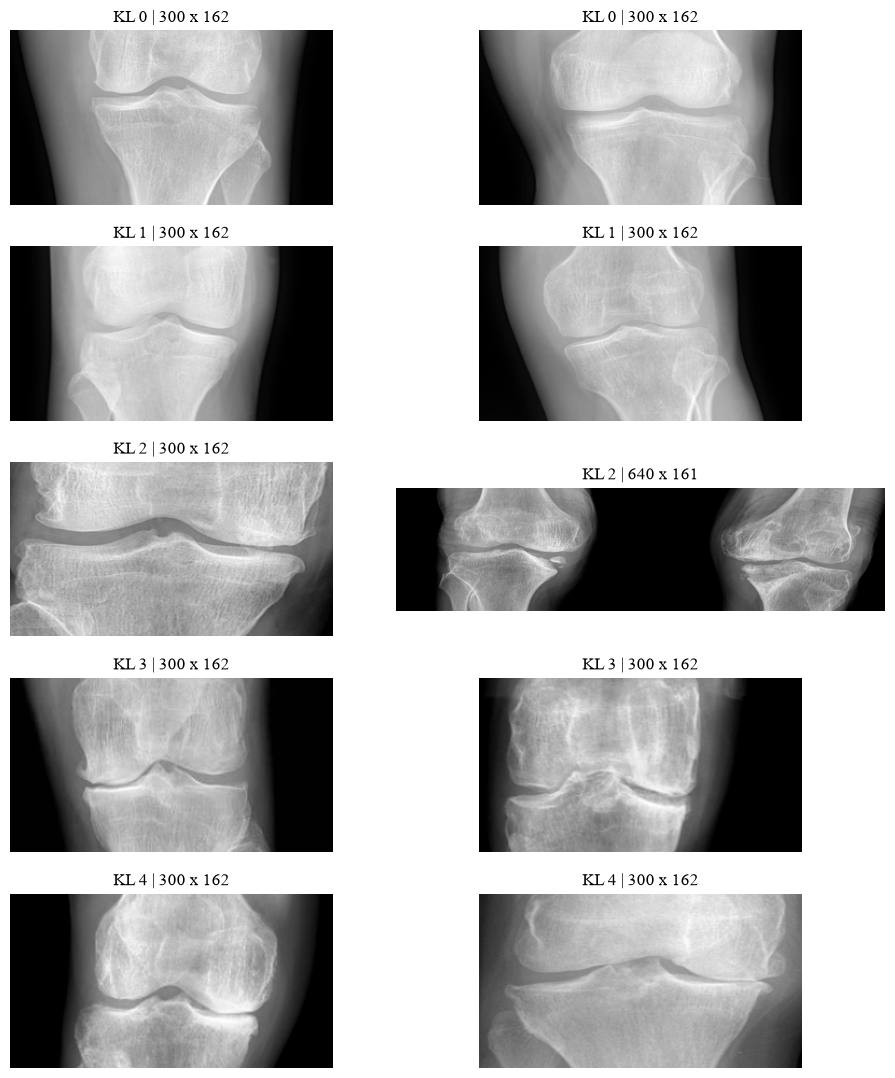

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman'],
                     'font.size': 14, 'savefig.dpi': 400, 'savefig.bbox': 'tight'})


def load_gray(path):
    """Load any image as 8-bit grayscale; 16-bit images are rescaled rather than clipped."""
    with Image.open(path) as img:
        arr = np.asarray(img)
    if arr.ndim == 3:
        arr = arr[..., :3].mean(axis=2)
    arr = arr.astype(np.float32)
    if arr.max() > 255:
        arr = 255 * (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr.astype(np.uint8)


size_counts, mode_counts = Counter(), Counter()
for path in ext['path']:
    with Image.open(path) as img:
        size_counts[img.size] += 1
        mode_counts[img.mode] += 1
print(f"Image sizes (width, height), all {len(ext)} images: {dict(size_counts.most_common(8))}")
print(f"Image modes: {dict(mode_counts)}")

rng = np.random.default_rng(0)
consensus = ext[ext['consensus']]
fig, axes = plt.subplots(5, 2, figsize=(10, 11))
for k in range(5):
    picks = rng.choice(consensus.index[consensus['expert1'] == k], 2, replace=False)
    for c, i in enumerate(picks):
        arr = load_gray(consensus.loc[i, 'path'])
        axes[k, c].imshow(arr, cmap='gray')
        axes[k, c].set_title(f"KL {k} | {arr.shape[1]} x {arr.shape[0]}", fontsize=12)
        axes[k, c].axis('off')
fig.tight_layout()
fig.savefig(os.path.join(EXT_OUT, 'external_preview.png'))
plt.show()

Single-knee images kept: 1410 | bilateral images excluded: 166
Single-knee, consensus labels per KL grade: [418, 434, 182, 165, 206]


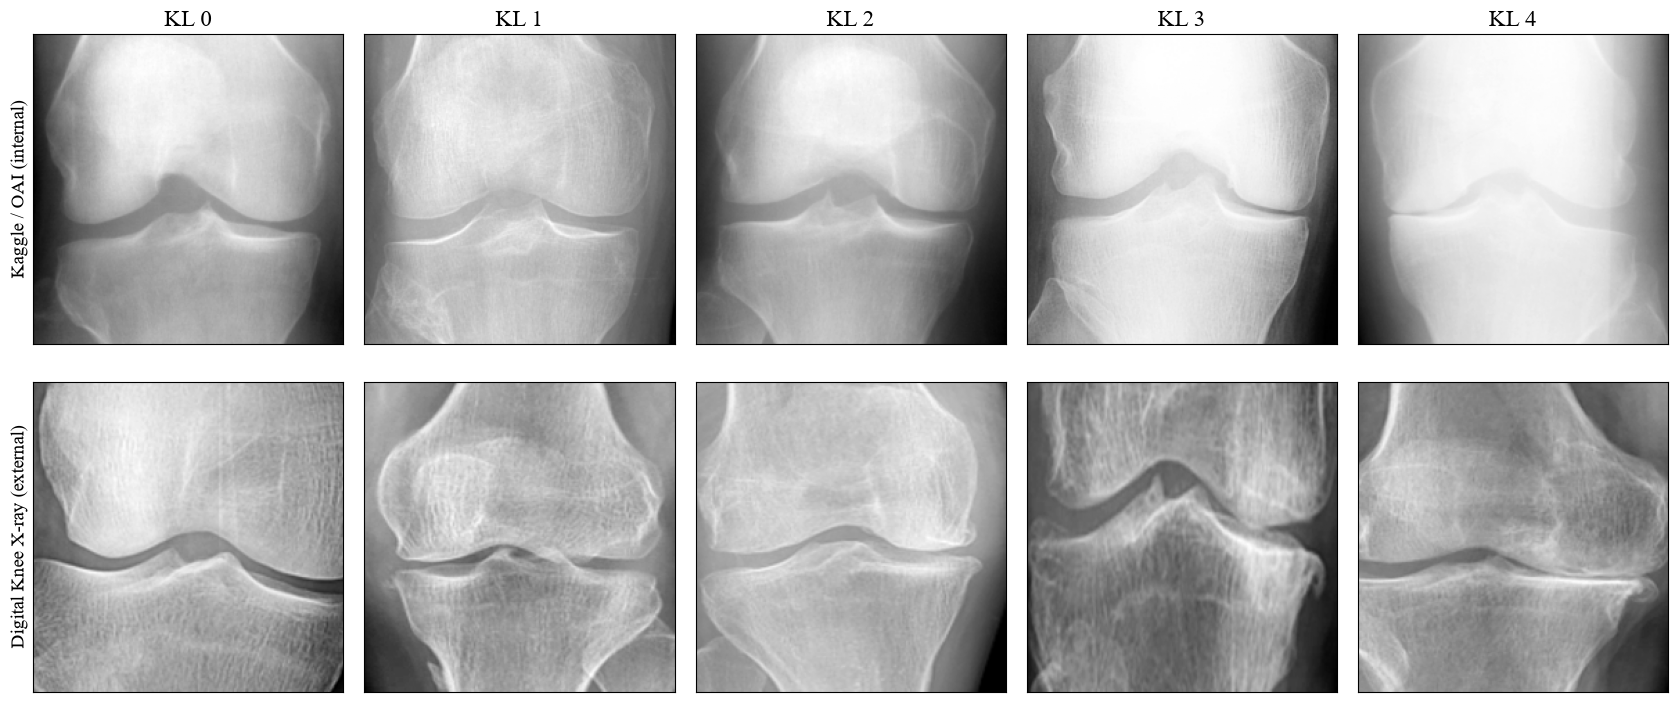

In [5]:
KAGGLE_TEST = r'E:\KNEE_fewshot\data\data\test'


def center_square(arr):
    """Crop the central square of a single-knee image (removes the dark side margins)."""
    h, w = arr.shape
    side = min(h, w)
    top, left = (h - side) // 2, (w - side) // 2
    return arr[top:top + side, left:left + side]

widths = []
for path in ext['path']:
    with Image.open(path) as img:
        widths.append(img.size[0])
ext['width'] = widths
ext['bilateral'] = ext['width'] > 2 * 162   # 640 x 161 images show two knees side by side

ext_single = ext[~ext['bilateral']].reset_index(drop=True)
print(f"Single-knee images kept: {len(ext_single)} | bilateral images excluded: {ext['bilateral'].sum()}")
print(f"Single-knee, consensus labels per KL grade: "
      f"{np.bincount(ext_single.loc[ext_single['consensus'], 'expert1'], minlength=5).tolist()}")
ext_single.drop(columns=['hash']).to_csv(os.path.join(EXT_OUT, 'external_single_knee.csv'), index=False)

rng = np.random.default_rng(1)
fig, axes = plt.subplots(2, 5, figsize=(17, 7.6))
for k in range(5):
    kaggle_files = sorted(os.listdir(os.path.join(KAGGLE_TEST, str(k))))
    kag = load_gray(os.path.join(KAGGLE_TEST, str(k), kaggle_files[rng.integers(len(kaggle_files))]))
    axes[0, k].imshow(np.asarray(Image.fromarray(kag).resize((224, 224))), cmap='gray')
    axes[0, k].set_title(f"KL {k}")

    pool = ext_single.index[(ext_single['expert1'] == k) & ext_single['consensus']]
    crop = center_square(load_gray(ext_single.loc[rng.choice(pool), 'path']))
    axes[1, k].imshow(np.asarray(Image.fromarray(crop).resize((224, 224))), cmap='gray')
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
axes[0, 0].set_ylabel('Kaggle / OAI (internal)')
axes[1, 0].set_ylabel('Digital Knee X-ray (external)')
fig.tight_layout()
fig.savefig(os.path.join(EXT_OUT, 'fig_internal_vs_external_examples.png'))
fig.savefig(os.path.join(EXT_OUT, 'fig_internal_vs_external_examples.pdf'))
plt.show()

In [6]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

REVISION = r'E:\KNEE_fewshot\revision'
RUNS_DIR = os.path.join(REVISION, 'runs')
PRED_DIR = os.path.join(EXT_OUT, 'predictions')
os.makedirs(PRED_DIR, exist_ok=True)

MODELS = ['vanilla', 'baseline', 'ordinal', 'attention', 'full']
BACKBONES = ['resnet18', 'densenet121']
SEEDS = [0, 1, 2]
RUN_NAMES = [f"{m}_{b}_seed{s}" for m in MODELS for b in BACKBONES for s in SEEDS]


class CBAM(nn.Module):
    """Same definition as in 01_train.ipynb."""

    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
        self.spatial = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        channel_att = torch.sigmoid(self.mlp(F.adaptive_avg_pool2d(x, 1)) +
                                    self.mlp(F.adaptive_max_pool2d(x, 1)))
        x = x * channel_att
        pooled = torch.cat([x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)], dim=1)
        return x * torch.sigmoid(self.spatial(pooled))


class EmbeddingNet(nn.Module):
    """Same architecture as in 01_train.ipynb; weights come from the checkpoint."""

    def __init__(self, backbone, use_attention, reduction=16):
        super().__init__()
        if backbone == 'resnet18':
            base = models.resnet18(weights=None)
            self.features = nn.Sequential(*list(base.children())[:-2])
            self.out_dim = 512
        else:
            base = models.densenet121(weights=None)
            self.features = nn.Sequential(base.features, nn.ReLU(inplace=True))
            self.out_dim = 1024
        self.attention = CBAM(self.out_dim, reduction) if use_attention else None

    def forward(self, x):
        fmap = self.features(x)
        if self.attention is not None:
            fmap = self.attention(fmap)
        return F.adaptive_avg_pool2d(fmap, 1).flatten(1)


class VanillaClassifier(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.encoder = EmbeddingNet(backbone, use_attention=False)
        self.head = nn.Linear(self.encoder.out_dim, 5)

    def forward(self, x):
        return self.head(self.encoder(x))


# Preprocess every external image once: 8-bit grayscale, central square crop, 224 x 224
t0 = time.time()
ext_images = np.stack([
    np.asarray(Image.fromarray(center_square(load_gray(p))).resize((224, 224), Image.BILINEAR))
    for p in ext_single['path']
])
print(f"Preprocessed {len(ext_images)} images in {time.time() - t0:.0f} s")

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def to_batch(gray_uint8):
    # Grayscale replicated to three channels, as in training (PIL convert('RGB'))
    x = torch.from_numpy(gray_uint8).float().div(255).unsqueeze(1).repeat(1, 3, 1, 1)
    return (x - MEAN) / STD


@torch.no_grad()
def run_external(run):
    model_type, backbone, _ = run.split('_')
    state = torch.load(os.path.join(RUNS_DIR, run, 'best_model.pth'), map_location='cpu')
    saved = np.load(os.path.join(RUNS_DIR, run, 'outputs.npz'))
    if model_type == 'vanilla':
        net = VanillaClassifier(backbone)
        net.load_state_dict(state)
        encoder = net.encoder
    else:
        net = EmbeddingNet(backbone, use_attention=model_type in ('attention', 'full'))
        net.load_state_dict(state)
        encoder = net
    net.eval()

    embs, logits = [], []
    for s in range(0, len(ext_images), 64):
        emb = encoder(to_batch(ext_images[s:s + 64]))
        embs.append(emb)
        if model_type == 'vanilla':
            logits.append(net.head(emb))
    emb = torch.cat(embs)
    if model_type == 'vanilla':
        logits = torch.cat(logits)
    else:
        # Prototypes are the mean Kaggle training embeddings; no external data is used
        logits = -torch.cdist(emb, torch.from_numpy(saved['prototypes']))
    return dict(emb=emb.numpy().astype(np.float16), logits=logits.numpy(),
                probs=F.softmax(logits, dim=1).numpy(), preds=logits.argmax(1).numpy())


for run in RUN_NAMES:
    out_path = os.path.join(PRED_DIR, f"{run}.npz")
    if os.path.exists(out_path):
        continue
    t0 = time.time()
    np.savez_compressed(out_path, **run_external(run))
    print(f"{run}: {time.time() - t0:.0f} s")

print(f"Prediction files: {len(os.listdir(PRED_DIR))} / {len(RUN_NAMES)}")

Preprocessed 1410 images in 5 s
Prediction files: 30 / 30


In [7]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# The same radiograph is sometimes stored more than once (e.g. 8-bit and 16-bit copies),
# which exact file hashes do not detect. Near-duplicates are found on 32 x 32 thumbnails.
NEAR_DUP_CORR = 0.98

thumbs = np.stack([np.asarray(Image.fromarray(img).resize((32, 32), Image.BILINEAR), dtype=np.float32)
                   for img in ext_images]).reshape(len(ext_images), -1)
thumbs = (thumbs - thumbs.mean(axis=1, keepdims=True)) / (thumbs.std(axis=1, keepdims=True) + 1e-8)
pix_corr = thumbs @ thumbs.T / thumbs.shape[1]
np.fill_diagonal(pix_corr, 0)

n_groups, group = connected_components(csr_matrix(pix_corr >= NEAR_DUP_CORR), directed=False)
ext_single['dup_group'] = group

keep = np.zeros(len(ext_single), dtype=bool)
dup_groups = conflict_groups = 0
for _, idx in ext_single.groupby('dup_group').groups.items():
    idx = np.sort(np.asarray(idx))
    if len(idx) > 1:
        dup_groups += 1
        if ext_single.loc[idx, 'expert1'].nunique() > 1 or ext_single.loc[idx, 'expert2'].nunique() > 1:
            conflict_groups += 1
            continue  # the same image carries different grades; the correct label is unknown
    keep[idx[0]] = True

ext_single['keep'] = keep
cons_mask = (ext_single['consensus'] & ext_single['keep']).to_numpy()
ext_single.drop(columns=['hash']).to_csv(os.path.join(EXT_OUT, 'external_single_knee.csv'), index=False)

in_groups = ext_single.groupby('dup_group')['dup_group'].transform('size').gt(1).sum()
print(f"Images in near-duplicate groups: {in_groups} ({dup_groups} groups)")
print(f"Groups with conflicting grades (removed entirely): {conflict_groups}")
print(f"Images kept: {keep.sum()} of {len(ext_single)}")
print(f"Consensus images kept: {cons_mask.sum()}, per KL grade "
      f"{np.bincount(ext_single.loc[cons_mask, 'expert1'], minlength=5).tolist()}")

Images in near-duplicate groups: 179 (67 groups)
Groups with conflicting grades (removed entirely): 4
Images kept: 1294 of 1410
Consensus images kept: 1292, per KL grade [358, 409, 166, 155, 204]


In [13]:
K = 5
N_BOOT = 2000
QWK_WEIGHTS = np.subtract.outer(np.arange(K), np.arange(K)) ** 2 / (K - 1) ** 2
MODEL_LABELS = {'vanilla': 'Softmax CNN', 'baseline': 'ProtoNet', 'ordinal': 'ProtoNet + Ordinal',
                'attention': 'ProtoNet + CBAM', 'full': 'ProtoNet + Ordinal + CBAM'}
BACKBONE_LABELS = {'resnet18': 'ResNet-18', 'densenet121': 'DenseNet-121'}
TAB_DIR = os.path.join(REVISION, 'tables')


def confusion(y_true, y_pred):
    return np.bincount(K * y_true + y_pred, minlength=K * K).reshape(K, K)


def metrics_from_cm(cm):
    n = cm.sum()
    tp = np.diag(cm)
    col, row = cm.sum(axis=0), cm.sum(axis=1)
    prec = np.divide(tp, col, out=np.zeros(K), where=col > 0)
    rec = np.divide(tp, row, out=np.zeros(K), where=row > 0)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros(K), where=(prec + rec) > 0)
    qwk = 1 - (QWK_WEIGHTS * cm).sum() / (QWK_WEIGHTS * np.outer(row, col) / n).sum()
    dist = np.abs(np.subtract.outer(np.arange(K), np.arange(K)))
    out = dict(accuracy=tp.sum() / n, f1_macro=f1.mean(), mae=(dist * cm).sum() / n,
               qwk=qwk, within_one=cm[dist <= 1].sum() / n)
    out.update({f'f1_kl{k}': f1[k] for k in range(K)})
    return out


ext_preds = {run: np.load(os.path.join(PRED_DIR, f"{run}.npz"))['preds'] for run in RUN_NAMES}
cons_mask = (ext_single['consensus'] & ext_single['keep']).to_numpy()
label_sets = {
    'consensus': (ext_single['expert1'].to_numpy()[cons_mask], cons_mask),
    'expert1': (ext_single['expert1'].to_numpy()[keep], keep),
    'expert2': (ext_single['expert2'].to_numpy()[keep], keep),
}

rows = []
for run in RUN_NAMES:
    model, backbone, seed_tag = run.split('_')
    for name, (y, mask) in label_sets.items():
        rows.append(dict(model=model, backbone=backbone, seed=int(seed_tag.replace('seed', '')),
                         labels=name, **metrics_from_cm(confusion(y, ext_preds[run][mask]))))
ext_df = pd.DataFrame(rows)
ext_df.to_csv(os.path.join(EXT_OUT, 'external_all_runs.csv'), index=False)

SHOW = ['accuracy', 'f1_macro', 'f1_kl0', 'f1_kl1', 'f1_kl2', 'f1_kl3', 'f1_kl4', 'mae', 'qwk', 'within_one']
internal = pd.read_csv(os.path.join(TAB_DIR, 'summary_mean_std.csv')).set_index(['backbone', 'model'])
cons = ext_df[ext_df['labels'] == 'consensus'].groupby(['backbone', 'model'], sort=False)[SHOW].agg(['mean', 'std'])

table_rows = []
for backbone in BACKBONES:
    for model in MODELS:
        r = cons.loc[(backbone, model)]
        table_rows.append(dict(
            Backbone=BACKBONE_LABELS[backbone], Model=MODEL_LABELS[model],
            **{m: f"{r[(m, 'mean')]:.3f} ± {r[(m, 'std')]:.3f}" for m in SHOW},
            internal_f1_macro=f"{internal.loc[(backbone, model), 'f1_macro_mean']:.3f}",
            internal_f1_kl1=f"{internal.loc[(backbone, model), 'f1_kl1_mean']:.3f}"))
ext_table = pd.DataFrame(table_rows)
ext_table.to_csv(os.path.join(EXT_OUT, 'table_external_results.csv'), index=False)

pd.set_option('display.width', 260)
print(f"External test set (consensus labels, n = {cons_mask.sum()}), mean ± SD over 3 seeds")
print(ext_table[['Backbone', 'Model', 'accuracy', 'f1_macro', 'mae', 'qwk', 'within_one',
                 'internal_f1_macro']].to_string(index=False))
print("\nPer-grade F1 on the external set")
print(ext_table[['Backbone', 'Model', 'f1_kl0', 'f1_kl1', 'f1_kl2', 'f1_kl3', 'f1_kl4',
                 'internal_f1_kl1']].to_string(index=False))

print("\nMacro F1 by label source (mean over 3 seeds)")
by_source = ext_df.groupby(['backbone', 'model', 'labels'], sort=False)['f1_macro'].mean().unstack()
by_source.index = [f"{BACKBONE_LABELS[b]} / {MODEL_LABELS[m]}" for b, m in by_source.index]
print(by_source.round(3).to_string())

# Paired bootstrap on the consensus set: each prototypical variant minus the softmax CNN
STAT = ['accuracy', 'f1_macro', 'f1_kl1', 'qwk']
y_cons = label_sets['consensus'][0]
preds_cons = {run: ext_preds[run][cons_mask] for run in RUN_NAMES}
n_cons = len(y_cons)


def seed_avg(y, idx, model, backbone):
    vals = [metrics_from_cm(confusion(y[idx], preds_cons[f"{model}_{backbone}_seed{s}"][idx]))
            for s in SEEDS]
    return np.array([[v[m] for m in STAT] for v in vals]).mean(axis=0)


def holm(p):
    order, adj, running = np.argsort(p), np.empty(len(p)), 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(p) - rank) * p[i])
        adj[i] = min(1.0, running)
    return adj


rng = np.random.default_rng(3)
boot_idx = [rng.integers(0, n_cons, n_cons) for _ in range(N_BOOT)]
full_idx = np.arange(n_cons)
stat_rows = []
for backbone in BACKBONES:
    base_boot = np.array([seed_avg(y_cons, idx, 'vanilla', backbone) for idx in boot_idx])
    base_obs = seed_avg(y_cons, full_idx, 'vanilla', backbone)
    for model in MODELS[1:]:
        dist = np.array([seed_avg(y_cons, idx, model, backbone) for idx in boot_idx]) - base_boot
        obs = seed_avg(y_cons, full_idx, model, backbone) - base_obs
        lo, hi = np.percentile(dist, [2.5, 97.5], axis=0)
        p = np.minimum(1.0, 2 * np.minimum((dist <= 0).mean(axis=0), (dist >= 0).mean(axis=0)))
        for k, m in enumerate(STAT):
            stat_rows.append(dict(backbone=BACKBONE_LABELS[backbone],
                                  comparison=f"{MODEL_LABELS[model]} vs Softmax CNN", metric=m,
                                  diff=obs[k], ci_low=lo[k], ci_high=hi[k], p=p[k]))

ext_stats = pd.DataFrame(stat_rows)
ext_stats['p_holm'] = np.nan
for _, grp in ext_stats.groupby(['backbone', 'metric']):
    ext_stats.loc[grp.index, 'p_holm'] = holm(grp['p'].to_numpy())
ext_stats.to_csv(os.path.join(EXT_OUT, 'external_statistical_comparisons.csv'), index=False)

fmt_p = lambda v: '<0.001' if v < 0.001 else f"{v:.3f}"
print("\nExternal set, prototypical variant minus softmax CNN: diff [95% CI], p, Holm p")
for m in STAT:
    print(f"\n{m}")
    for _, r in ext_stats[ext_stats['metric'] == m].iterrows():
        print(f"  {r['backbone']:12s} {r['comparison']:40s} {r['diff']:+.3f} "
              f"[{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]  p={fmt_p(r['p'])}  p_holm={fmt_p(r['p_holm'])}")

External test set (consensus labels, n = 1292), mean ± SD over 3 seeds
    Backbone                     Model      accuracy      f1_macro           mae           qwk    within_one internal_f1_macro
   ResNet-18               Softmax CNN 0.360 ± 0.012 0.319 ± 0.012 0.886 ± 0.031 0.621 ± 0.018 0.797 ± 0.019             0.664
   ResNet-18                  ProtoNet 0.341 ± 0.075 0.331 ± 0.061 0.858 ± 0.133 0.638 ± 0.081 0.821 ± 0.052             0.681
   ResNet-18        ProtoNet + Ordinal 0.313 ± 0.050 0.310 ± 0.043 0.901 ± 0.104 0.618 ± 0.055 0.800 ± 0.056             0.686
   ResNet-18           ProtoNet + CBAM 0.345 ± 0.020 0.333 ± 0.026 0.846 ± 0.034 0.644 ± 0.028 0.824 ± 0.015             0.680
   ResNet-18 ProtoNet + Ordinal + CBAM 0.326 ± 0.040 0.317 ± 0.036 0.854 ± 0.065 0.631 ± 0.048 0.833 ± 0.025             0.675
DenseNet-121               Softmax CNN 0.357 ± 0.034 0.340 ± 0.022 0.877 ± 0.073 0.619 ± 0.043 0.785 ± 0.035             0.687
DenseNet-121                  ProtoNet 0

In [14]:
K_SHOTS = [1, 5, 10, 20]
N_EPISODES = 100

y_all = ext_single['expert1'].to_numpy()[cons_mask]
class_pool = [np.where(y_all == k)[0] for k in range(K)]
ext_emb = {run: np.load(os.path.join(PRED_DIR, f"{run}.npz"))['emb'].astype(np.float32)[cons_mask]
           for run in RUN_NAMES}

# The same support sets are used for every model, so comparisons are paired
rng = np.random.default_rng(4)
episodes = {shot: [np.concatenate([rng.choice(p, shot, replace=False) for p in class_pool])
                   for _ in range(N_EPISODES)] for shot in K_SHOTS}

adapt_rows = []
for run in RUN_NAMES:
    model, backbone, seed_tag = run.split('_')
    emb = ext_emb[run]
    base = metrics_from_cm(confusion(y_all, preds_cons[run]))
    adapt_rows.append(dict(model=model, backbone=backbone, seed=int(seed_tag.replace('seed', '')),
                           shot='0 (no adaptation)', **{m: base[m] for m in STAT}))
    for shot in K_SHOTS:
        ep_metrics = []
        for support in episodes[shot]:
            query = np.setdiff1d(np.arange(len(y_all)), support)
            protos = np.stack([emb[support[y_all[support] == k]].mean(axis=0) for k in range(K)])
            q = emb[query]
            pred = (-2 * q @ protos.T + (protos ** 2).sum(axis=1)).argmin(axis=1)
            m = metrics_from_cm(confusion(y_all[query], pred))
            ep_metrics.append([m[x] for x in STAT])
        ep_metrics = np.array(ep_metrics)
        adapt_rows.append(dict(model=model, backbone=backbone, seed=int(seed_tag.replace('seed', '')),
                               shot=str(shot), **{x: ep_metrics[:, i].mean() for i, x in enumerate(STAT)}))

adapt = pd.DataFrame(adapt_rows)
adapt.to_csv(os.path.join(EXT_OUT, 'external_kshot_adaptation.csv'), index=False)

SHOT_ORDER = ['0 (no adaptation)'] + [str(s) for s in K_SHOTS]
adapt_agg = adapt.groupby(['backbone', 'model', 'shot'])[STAT].agg(['mean', 'std'])
for metric in ['f1_macro', 'f1_kl1', 'accuracy', 'qwk']:
    print(f"\n{metric} on the external set after re-estimating prototypes from K external images per grade")
    print("(K = 0 uses each model as trained: softmax head or Kaggle prototypes)")
    for backbone in BACKBONES:
        print(f"  {BACKBONE_LABELS[backbone]}")
        for model in MODELS:
            cells = "  ".join(
                f"K={s.split()[0]}: {adapt_agg.loc[(backbone, model, s), (metric, 'mean')]:.3f}"
                f"±{adapt_agg.loc[(backbone, model, s), (metric, 'std')]:.3f}" for s in SHOT_ORDER)
            print(f"    {MODEL_LABELS[model]:28s} {cells}")


f1_macro on the external set after re-estimating prototypes from K external images per grade
(K = 0 uses each model as trained: softmax head or Kaggle prototypes)
  ResNet-18
    Softmax CNN                  K=0: 0.319±0.012  K=1: 0.350±0.004  K=5: 0.464±0.008  K=10: 0.492±0.008  K=20: 0.510±0.012
    ProtoNet                     K=0: 0.331±0.061  K=1: 0.366±0.008  K=5: 0.485±0.002  K=10: 0.516±0.002  K=20: 0.537±0.004
    ProtoNet + Ordinal           K=0: 0.310±0.043  K=1: 0.368±0.008  K=5: 0.479±0.012  K=10: 0.507±0.014  K=20: 0.526±0.011
    ProtoNet + CBAM              K=0: 0.333±0.026  K=1: 0.364±0.010  K=5: 0.458±0.017  K=10: 0.480±0.015  K=20: 0.494±0.016
    ProtoNet + Ordinal + CBAM    K=0: 0.317±0.036  K=1: 0.366±0.012  K=5: 0.460±0.012  K=10: 0.486±0.013  K=20: 0.502±0.011
  DenseNet-121
    Softmax CNN                  K=0: 0.340±0.022  K=1: 0.353±0.003  K=5: 0.482±0.011  K=10: 0.505±0.013  K=20: 0.524±0.015
    ProtoNet                     K=0: 0.271±0.048  K=1: 0.380±0.0

Difference from softmax CNN after K-shot adaptation (seed-averaged, paired support sets)
mean [2.5th, 97.5th percentile over 100 support sets], share of support sets favouring the prototypical model

f1_macro
  ResNet-18    K=5   ProtoNet vs Softmax CNN                  +0.021 [-0.017, +0.061]  better in 80%
  ResNet-18    K=5   ProtoNet + Ordinal vs Softmax CNN        +0.015 [-0.025, +0.058]  better in 77%
  ResNet-18    K=5   ProtoNet + CBAM vs Softmax CNN           -0.006 [-0.056, +0.038]  better in 41%
  ResNet-18    K=5   ProtoNet + Ordinal + CBAM vs Softmax CNN -0.004 [-0.055, +0.035]  better in 43%
  ResNet-18    K=20  ProtoNet vs Softmax CNN                  +0.027 [-0.002, +0.053]  better in 95%
  ResNet-18    K=20  ProtoNet + Ordinal vs Softmax CNN        +0.016 [-0.013, +0.039]  better in 86%
  ResNet-18    K=20  ProtoNet + CBAM vs Softmax CNN           -0.015 [-0.047, +0.010]  better in 18%
  ResNet-18    K=20  ProtoNet + Ordinal + CBAM vs Softmax CNN -0.008 [-0.033, +0.018

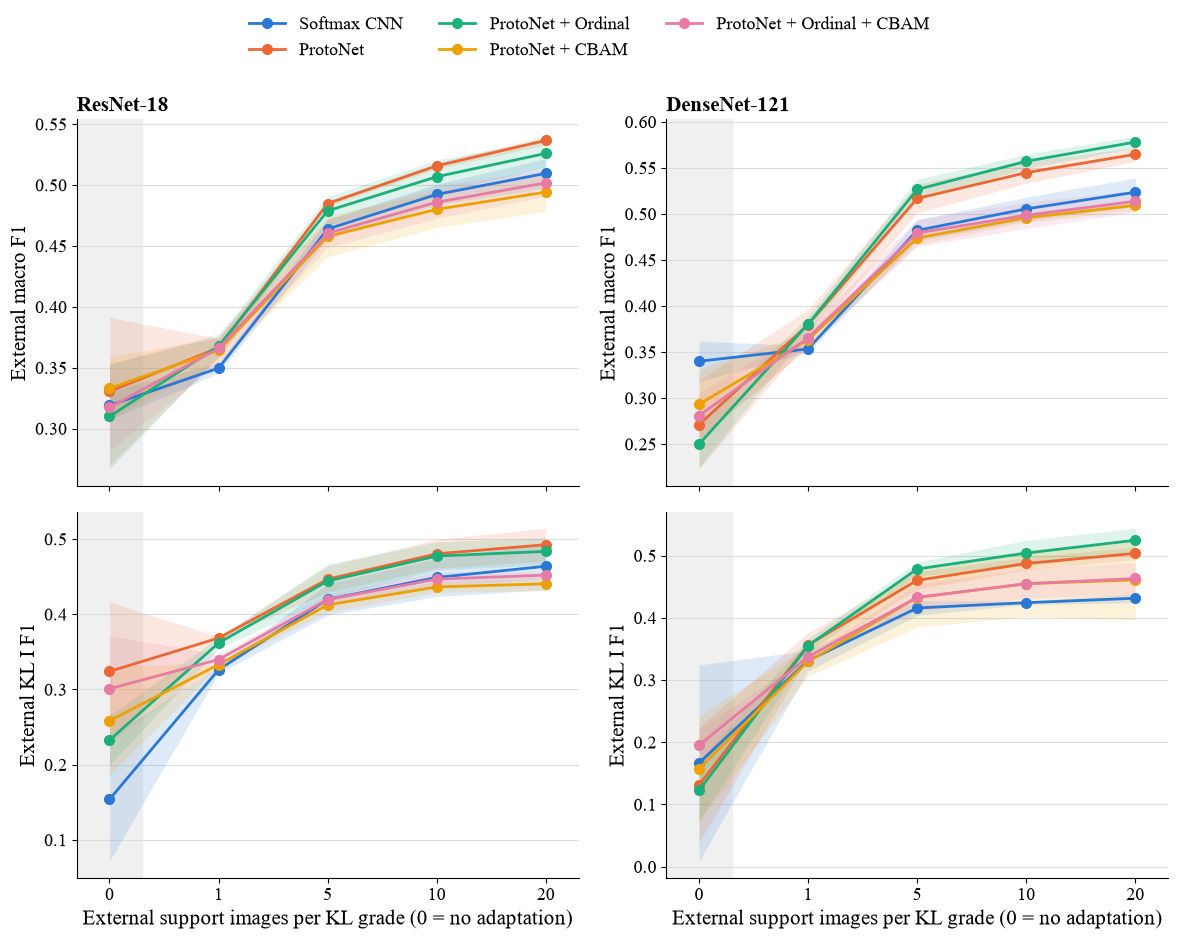

In [15]:
FIG_DIR = os.path.join(REVISION, 'figures')
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman'], 'mathtext.fontset': 'stix',
    'font.size': 14, 'axes.titlesize': 15, 'axes.labelsize': 15, 'xtick.labelsize': 13,
    'ytick.labelsize': 13, 'legend.fontsize': 13, 'savefig.dpi': 400, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True,
    'axes.grid': True, 'axes.grid.axis': 'y', 'grid.color': '#dddddd', 'grid.linewidth': 0.8,
})
MODEL_COLORS = dict(zip(MODELS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))


def episode_metrics(run, shot):
    emb = ext_emb[run]
    out = []
    for support in episodes[shot]:
        query = np.setdiff1d(np.arange(len(y_all)), support)
        protos = np.stack([emb[support[y_all[support] == k]].mean(axis=0) for k in range(K)])
        pred = (-2 * emb[query] @ protos.T + (protos ** 2).sum(axis=1)).argmin(axis=1)
        m = metrics_from_cm(confusion(y_all[query], pred))
        out.append([m[x] for x in STAT])
    return np.array(out)


ep = {(run, shot): episode_metrics(run, shot) for run in RUN_NAMES for shot in K_SHOTS}

diff_rows = []
for backbone in BACKBONES:
    for shot in K_SHOTS:
        base = np.mean([ep[(f"vanilla_{backbone}_seed{s}", shot)] for s in SEEDS], axis=0)
        for model in MODELS[1:]:
            d = np.mean([ep[(f"{model}_{backbone}_seed{s}", shot)] for s in SEEDS], axis=0) - base
            for i, m in enumerate(STAT):
                diff_rows.append(dict(backbone=BACKBONE_LABELS[backbone], shot=shot,
                                      comparison=f"{MODEL_LABELS[model]} vs Softmax CNN", metric=m,
                                      mean_diff=d[:, i].mean(),
                                      interval_low=np.percentile(d[:, i], 2.5),
                                      interval_high=np.percentile(d[:, i], 97.5),
                                      share_better=(d[:, i] > 0).mean()))
adapt_diff = pd.DataFrame(diff_rows)
adapt_diff.to_csv(os.path.join(EXT_OUT, 'external_adaptation_differences.csv'), index=False)

print("Difference from softmax CNN after K-shot adaptation (seed-averaged, paired support sets)")
print("mean [2.5th, 97.5th percentile over 100 support sets], share of support sets favouring the prototypical model")
for m in ['f1_macro', 'f1_kl1', 'qwk']:
    print(f"\n{m}")
    sub = adapt_diff[(adapt_diff['metric'] == m) & (adapt_diff['shot'].isin([5, 20]))]
    for _, r in sub.iterrows():
        print(f"  {r['backbone']:12s} K={r['shot']:<3d} {r['comparison']:40s} {r['mean_diff']:+.3f} "
              f"[{r['interval_low']:+.3f}, {r['interval_high']:+.3f}]  better in {100 * r['share_better']:.0f}%")

# Figure: external macro F1 and KL I F1 against the number of external support images
xlabels = ['0', '1', '5', '10', '20']
xpos = np.arange(len(xlabels))
fig, axes = plt.subplots(2, 2, figsize=(12, 9.5), sharex=True)
for c, backbone in enumerate(BACKBONES):
    for r, (metric, ylabel) in enumerate([('f1_macro', 'External macro F1'), ('f1_kl1', 'External KL I F1')]):
        ax = axes[r, c]
        for model in MODELS:
            mu = [adapt_agg.loc[(backbone, model, s), (metric, 'mean')] for s in SHOT_ORDER]
            sd = [adapt_agg.loc[(backbone, model, s), (metric, 'std')] for s in SHOT_ORDER]
            mu, sd = np.array(mu), np.array(sd)
            ax.plot(xpos, mu, marker='o', markersize=7, linewidth=2,
                    color=MODEL_COLORS[model], label=MODEL_LABELS[model])
            ax.fill_between(xpos, mu - sd, mu + sd, color=MODEL_COLORS[model], alpha=0.15, linewidth=0)
        ax.axvspan(-0.3, 0.3, color='#f0f0f0', zorder=0)
        ax.set_xticks(xpos, xlabels)
        ax.set_xlim(-0.3, len(xlabels) - 0.7)
        ax.set_ylabel(ylabel)
        if r == 0:
            ax.set_title(BACKBONE_LABELS[backbone], loc='left', fontweight='bold')
        if r == 1:
            ax.set_xlabel('External support images per KL grade (0 = no adaptation)')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.92])
for ext_name in ('png', 'pdf'):
    fig.savefig(os.path.join(FIG_DIR, f'fig_external_kshot.{ext_name}'))
plt.show()

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

PROBE_MODELS = ['vanilla', 'baseline', 'ordinal']
PROBE_SHOTS = [5, 10, 20]


def probe_episode_metrics(run, shot):
    emb = ext_emb[run]
    out = []
    for support in episodes[shot]:
        query = np.setdiff1d(np.arange(len(y_all)), support)
        scaler = StandardScaler().fit(emb[support])
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(scaler.transform(emb[support]), y_all[support])
        pred = clf.predict(scaler.transform(emb[query]))
        m = metrics_from_cm(confusion(y_all[query], pred))
        out.append([m[x] for x in STAT])
    return np.array(out)


probe_rows = []
for backbone in BACKBONES:
    for model in PROBE_MODELS:
        for s in SEEDS:
            run = f"{model}_{backbone}_seed{s}"
            for shot in PROBE_SHOTS:
                for method, values in [('prototypes', ep[(run, shot)]),
                                       ('logistic regression', probe_episode_metrics(run, shot))]:
                    probe_rows.append(dict(backbone=backbone, model=model, seed=s, shot=shot,
                                           adaptation=method,
                                           **{m: values[:, i].mean() for i, m in enumerate(STAT)}))

probe = pd.DataFrame(probe_rows)
probe.to_csv(os.path.join(EXT_OUT, 'external_adaptation_linear_probe.csv'), index=False)
probe_agg = probe.groupby(['backbone', 'model', 'adaptation', 'shot'])[STAT].agg(['mean', 'std'])

for metric in ['f1_macro', 'f1_kl1', 'qwk']:
    print(f"\n{metric}: adaptation with K external images per grade (mean ± SD over 3 seeds)")
    for backbone in BACKBONES:
        print(f"  {BACKBONE_LABELS[backbone]}")
        for model in PROBE_MODELS:
            for method in ['prototypes', 'logistic regression']:
                cells = "  ".join(
                    f"K={k}: {probe_agg.loc[(backbone, model, method, k), (metric, 'mean')]:.3f}"
                    f"±{probe_agg.loc[(backbone, model, method, k), (metric, 'std')]:.3f}"
                    for k in PROBE_SHOTS)
                print(f"    {MODEL_LABELS[model]:20s} {method:20s} {cells}")


f1_macro: adaptation with K external images per grade (mean ± SD over 3 seeds)
  ResNet-18
    Softmax CNN          prototypes           K=5: 0.464±0.008  K=10: 0.492±0.008  K=20: 0.510±0.012
    Softmax CNN          logistic regression  K=5: 0.470±0.006  K=10: 0.513±0.009  K=20: 0.557±0.011
    ProtoNet             prototypes           K=5: 0.485±0.002  K=10: 0.516±0.002  K=20: 0.537±0.004
    ProtoNet             logistic regression  K=5: 0.483±0.005  K=10: 0.524±0.004  K=20: 0.561±0.008
    ProtoNet + Ordinal   prototypes           K=5: 0.479±0.012  K=10: 0.507±0.014  K=20: 0.526±0.011
    ProtoNet + Ordinal   logistic regression  K=5: 0.477±0.007  K=10: 0.522±0.008  K=20: 0.561±0.009
  DenseNet-121
    Softmax CNN          prototypes           K=5: 0.482±0.011  K=10: 0.505±0.013  K=20: 0.524±0.015
    Softmax CNN          logistic regression  K=5: 0.520±0.005  K=10: 0.563±0.005  K=20: 0.608±0.002
    ProtoNet             prototypes           K=5: 0.517±0.016  K=10: 0.545±0.012  K=

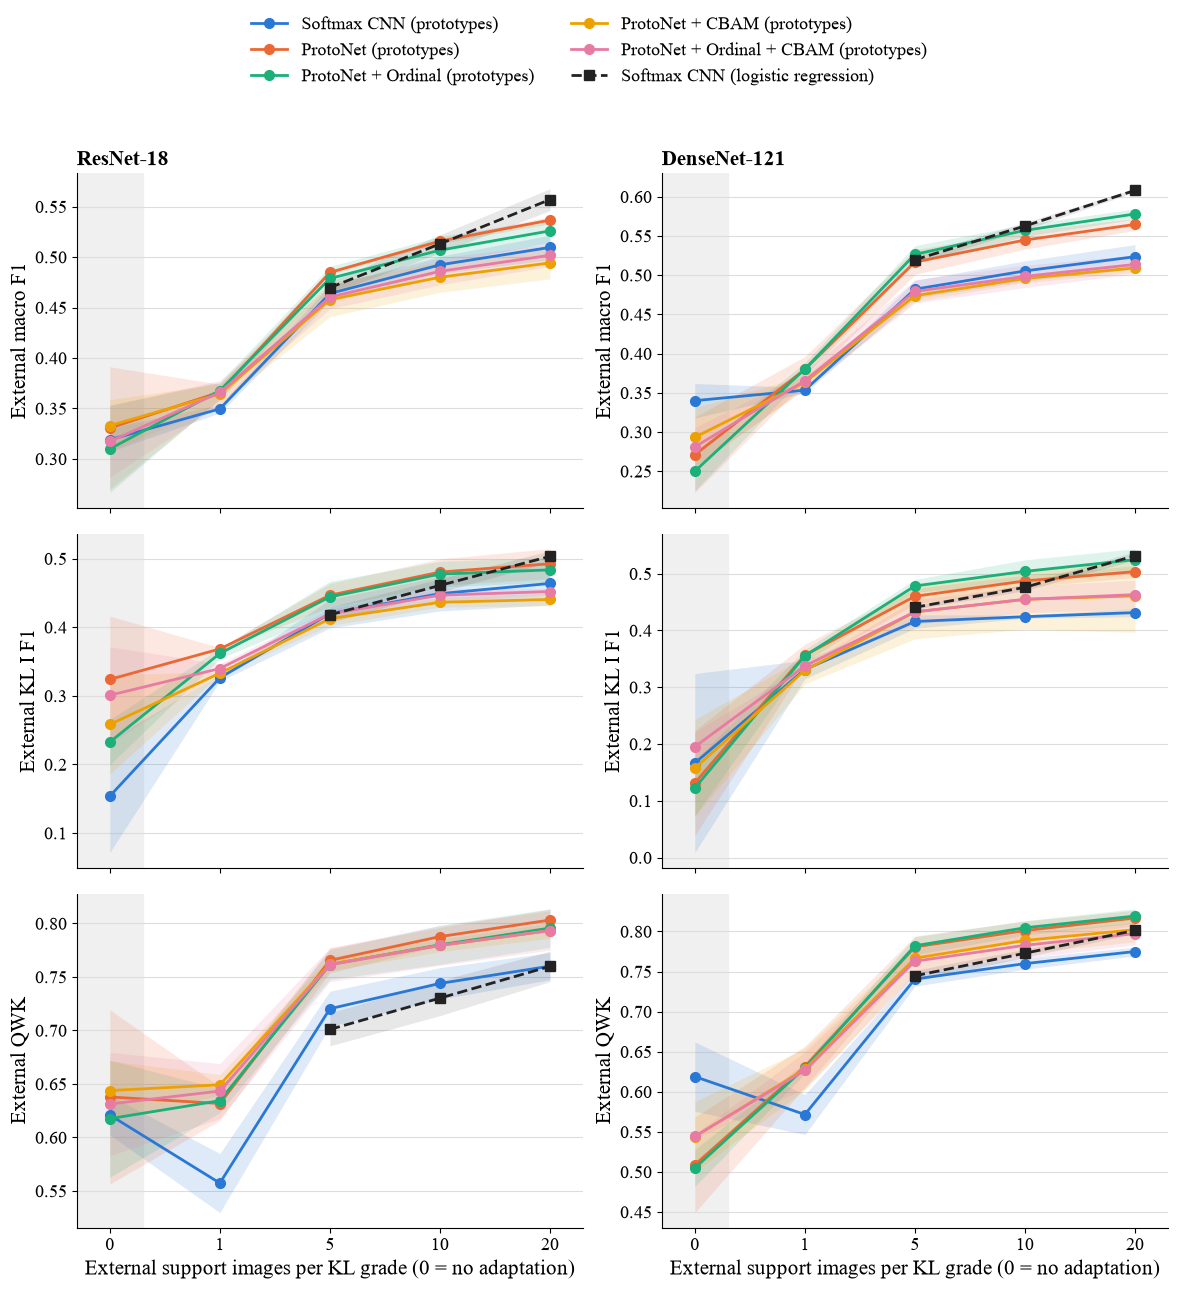

In [17]:
panels = [('f1_macro', 'External macro F1'), ('f1_kl1', 'External KL I F1'), ('qwk', 'External QWK')]
probe_x = [xlabels.index(str(k)) for k in PROBE_SHOTS]

fig, axes = plt.subplots(3, 2, figsize=(12, 13), sharex=True)
for c, backbone in enumerate(BACKBONES):
    for r, (metric, ylabel) in enumerate(panels):
        ax = axes[r, c]
        for model in MODELS:
            mu = np.array([adapt_agg.loc[(backbone, model, s), (metric, 'mean')] for s in SHOT_ORDER])
            sd = np.array([adapt_agg.loc[(backbone, model, s), (metric, 'std')] for s in SHOT_ORDER])
            ax.plot(xpos, mu, marker='o', markersize=7, linewidth=2,
                    color=MODEL_COLORS[model], label=f"{MODEL_LABELS[model]} (prototypes)")
            ax.fill_between(xpos, mu - sd, mu + sd, color=MODEL_COLORS[model], alpha=0.15, linewidth=0)
        mu = np.array([probe_agg.loc[(backbone, 'vanilla', 'logistic regression', k), (metric, 'mean')]
                       for k in PROBE_SHOTS])
        sd = np.array([probe_agg.loc[(backbone, 'vanilla', 'logistic regression', k), (metric, 'std')]
                       for k in PROBE_SHOTS])
        ax.plot(probe_x, mu, marker='s', markersize=7, linewidth=2, linestyle='--',
                color='#222222', label='Softmax CNN (logistic regression)')
        ax.fill_between(probe_x, mu - sd, mu + sd, color='#222222', alpha=0.10, linewidth=0)
        ax.axvspan(-0.3, 0.3, color='#f0f0f0', zorder=0)
        ax.set_xticks(xpos, xlabels)
        ax.set_xlim(-0.3, len(xlabels) - 0.7)
        ax.set_ylabel(ylabel)
        if r == 0:
            ax.set_title(BACKBONE_LABELS[backbone], loc='left', fontweight='bold')
        if r == len(panels) - 1:
            ax.set_xlabel('External support images per KL grade (0 = no adaptation)')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.90])
for ext_name in ('png', 'pdf'):
    fig.savefig(os.path.join(FIG_DIR, f'fig_external_kshot.{ext_name}'))
plt.show()